# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 62     |  |
| :-------------|:-------------|
| Student Thijn Holswilder | 6536387 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['naam1', 'naam2','naam3']

## Opdracht 1: Planning.

| Planning Groep: XX     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1 | Tijdstip |
| Mijlpaal 2 | Tijdstip |
| groep aanwezig 1| Tijdspanne |
| groep aanwezig 2| Tijdspanne |
| Pauze 1| Tijdspanne |
| Pauze 2| Tijdspanne |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [62]
<img src="opstelling-kalibreren-subwoofer.jpeg" width="400">

a = 0.0339 ± 0.0002
b = -0.04 ± 0.24


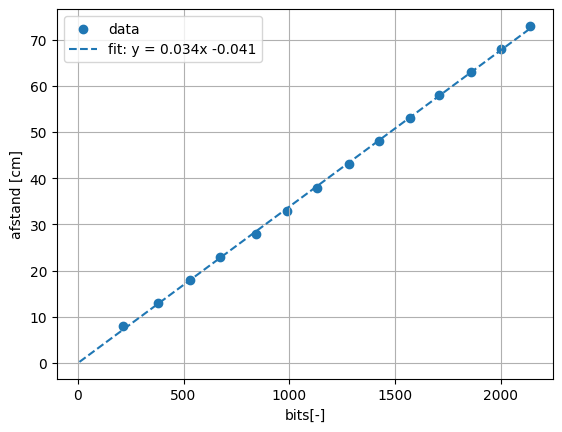

In [3]:
# Data
afstand = (90 - np.array([82, 77, 72, 67, 62, 57, 52, 47, 42, 37, 32, 27, 22, 17]))  # [cm]
bits = np.array([215, 380, 532, 673, 845, 988, 1133, 1284, 1423, 1570, 1707, 1860, 2000, 2140])

# Lineair model
def f(x, a, b):
    return a*x + b

# Fit
popt, pcov = curve_fit(f, bits, afstand)

a, b = popt
ua, ub = np.sqrt(np.diag(pcov))

print(f"a = {a:.4f} ± {ua:.4f}")
print(f"b = {b:.2f} ± {ub:.2f}")

# Fijne x voor plot
x_fit = np.linspace(min(afstand), max(bits), 100)
y_fit = f(x_fit, a, b)

# Plot
plt.figure()
plt.scatter(bits, afstand, label="data")
plt.plot(x_fit, y_fit, '--', label=f"fit: y = {a:.3f}x {b:.3f}")
plt.xlabel("bits[-]")
plt.ylabel("afstand [cm]")
plt.legend()
plt.grid()
plt.show()

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0   0  40   0  30  41
1   0  30   0  20  41
2  40   0  30   0  41
3  30   0  20   0  41


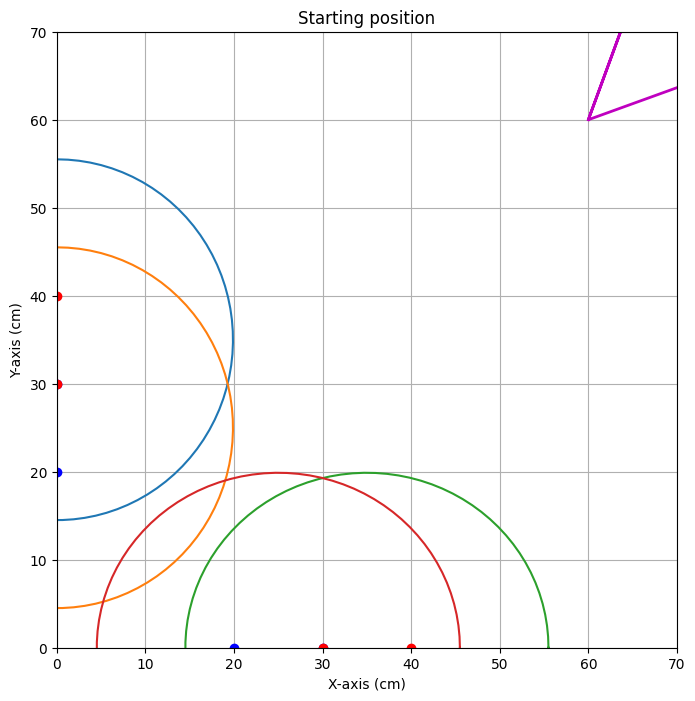


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=100.955


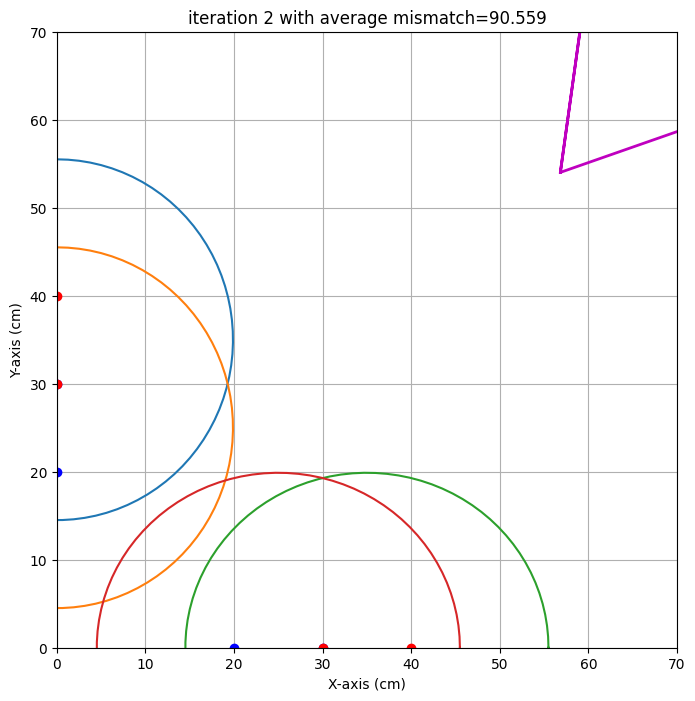

end iteration 2 with average mismatch=90.559


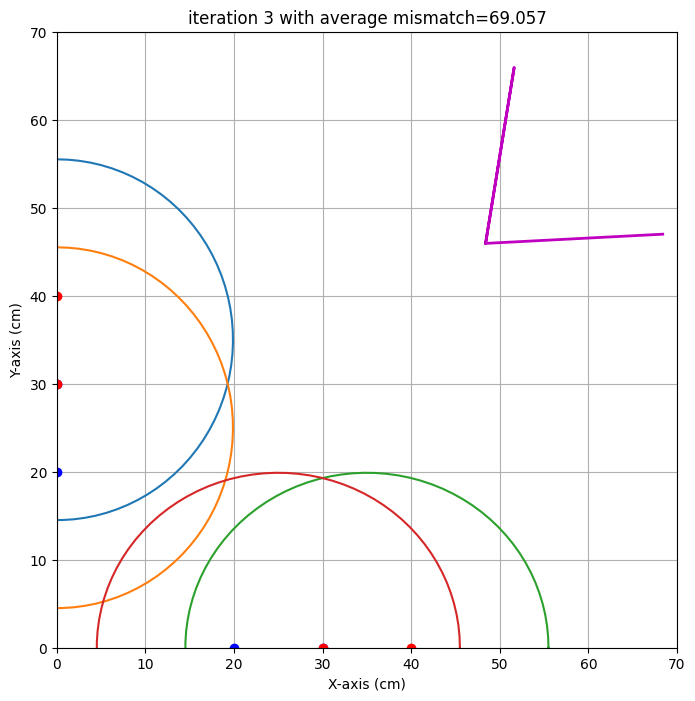

end iteration 3 with average mismatch=69.057


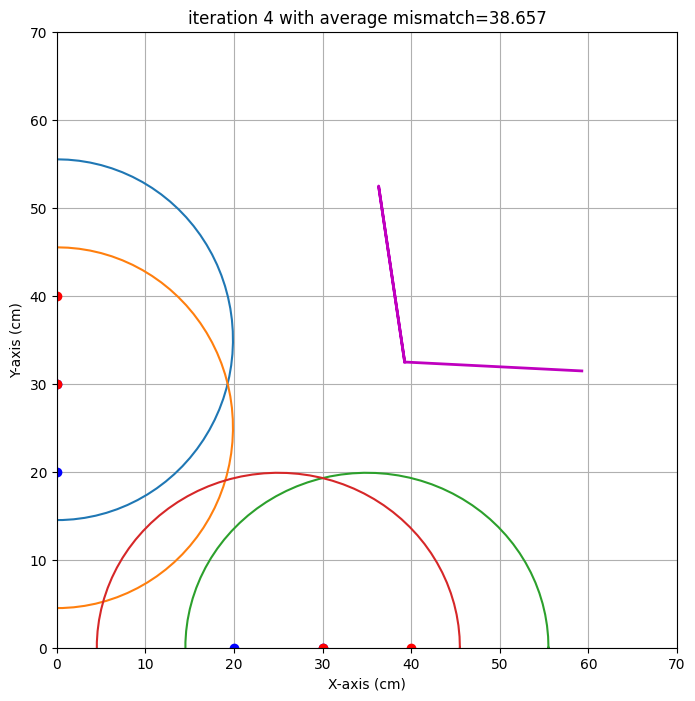

end iteration 4 with average mismatch=38.657


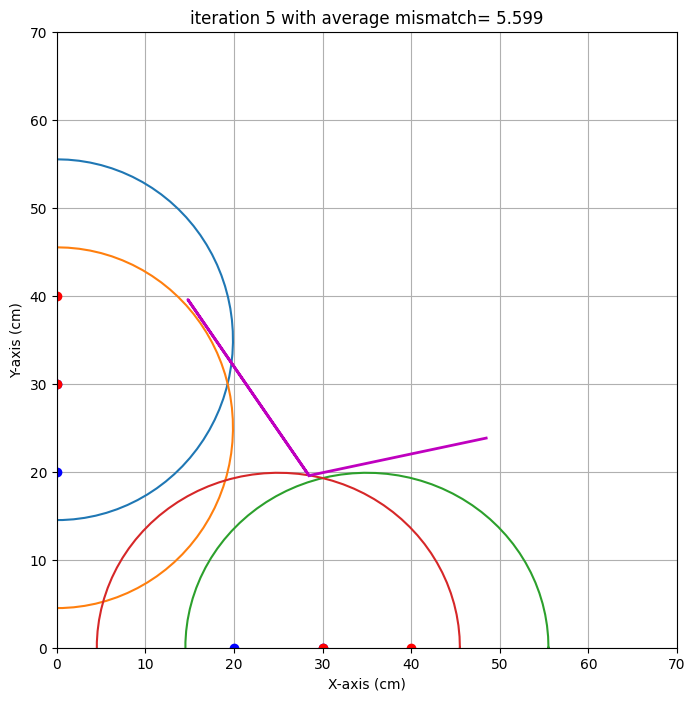

end iteration 5 with average mismatch= 5.599


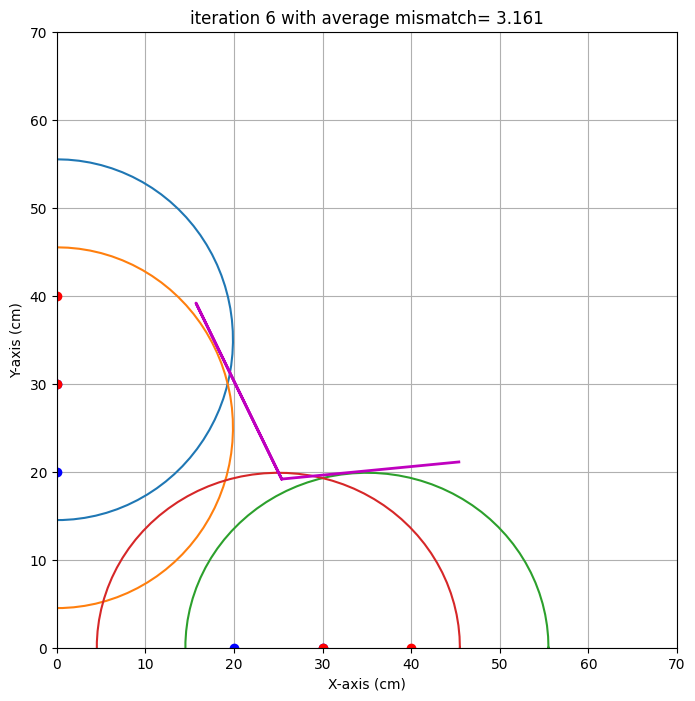

end iteration 6 with average mismatch= 3.161


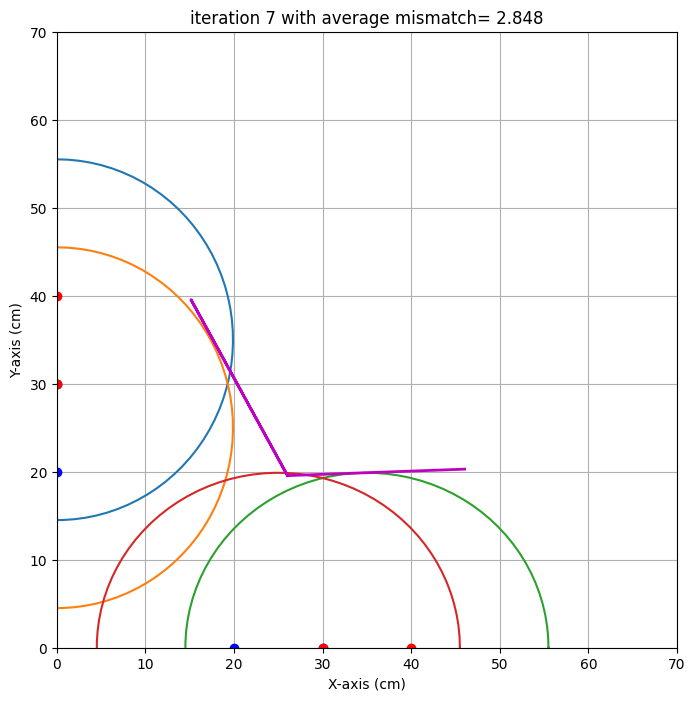

end iteration 7 with average mismatch= 2.848
end iteration 8 with average mismatch= 2.848


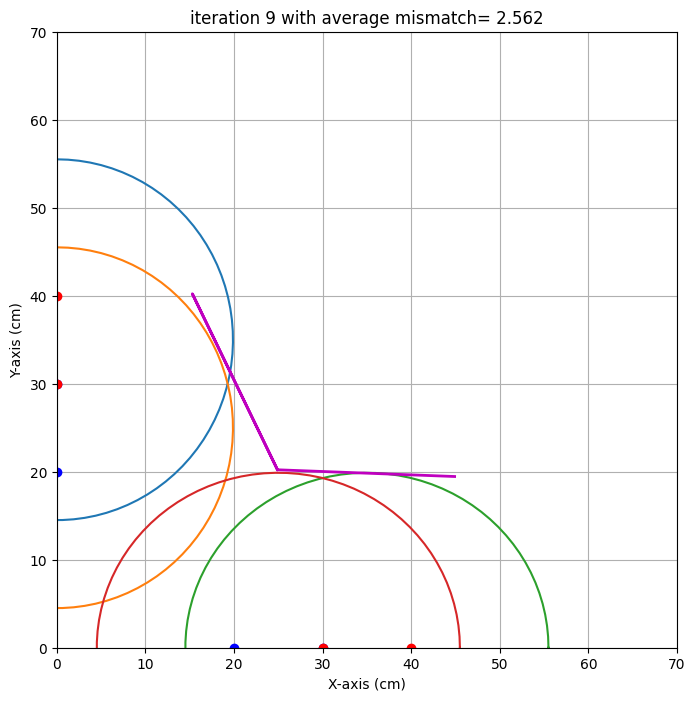

end iteration 9 with average mismatch= 2.562


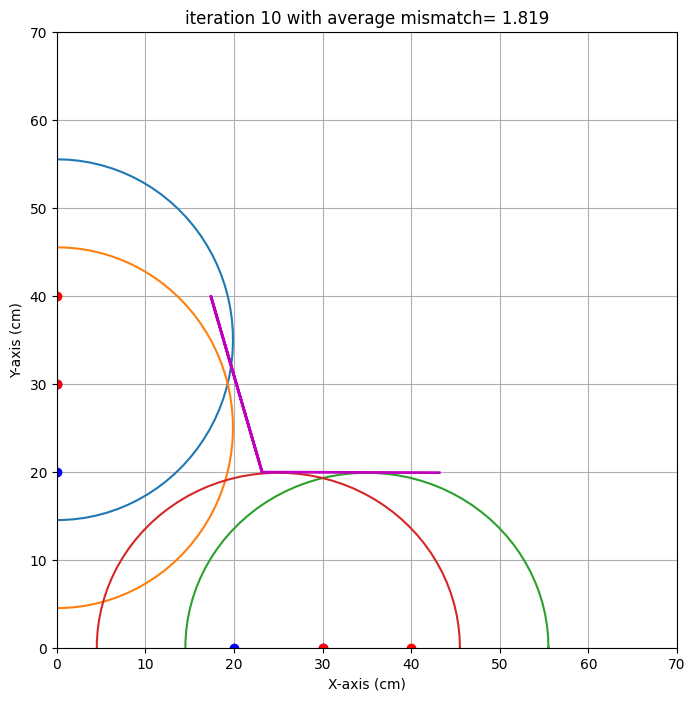

end iteration 10 with average mismatch= 1.819
end iteration 11 with average mismatch= 1.746
end iteration 12 with average mismatch= 1.739


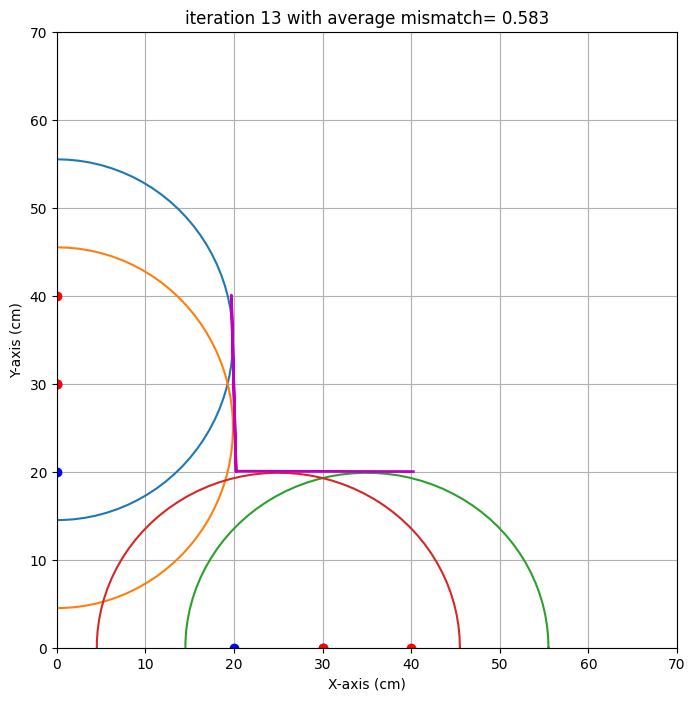

end iteration 13 with average mismatch= 0.583


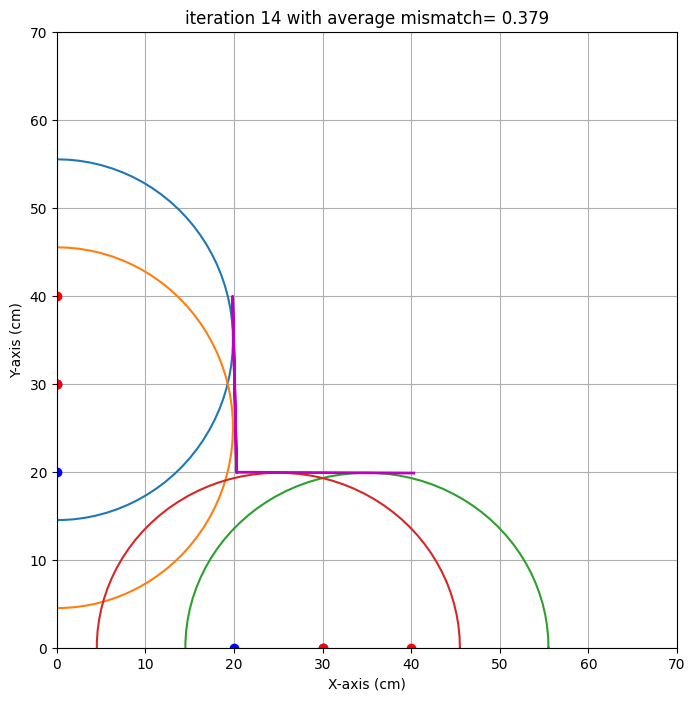

end iteration 14 with average mismatch= 0.379
end iteration 15 with average mismatch= 0.377


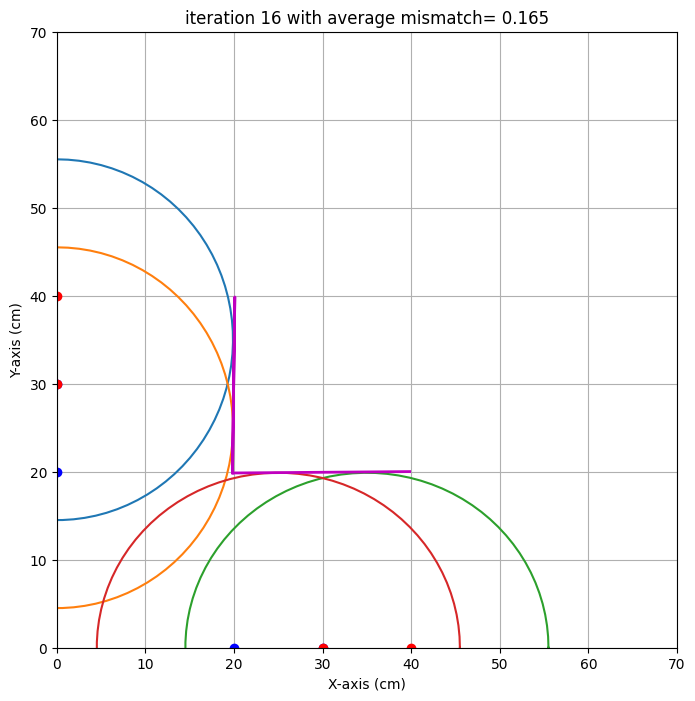

end iteration 16 with average mismatch= 0.165


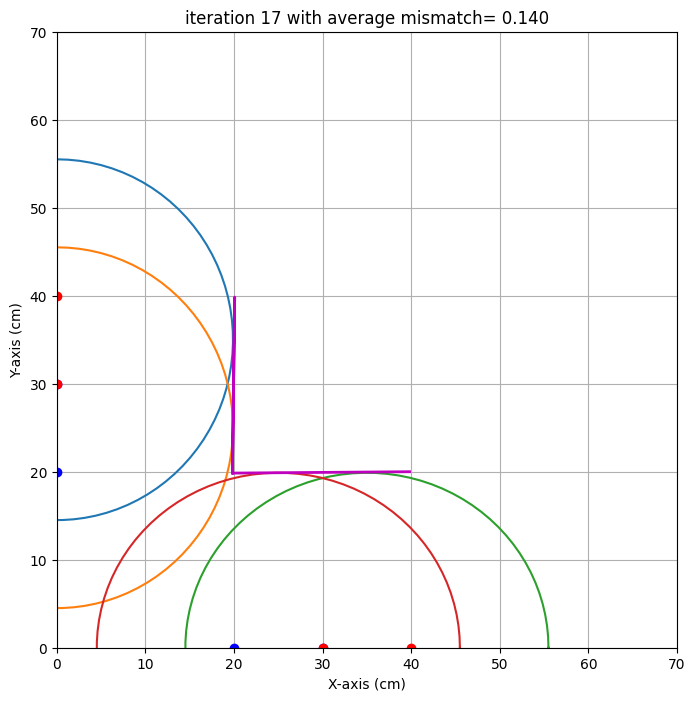

end iteration 17 with average mismatch= 0.140
end iteration 18 with average mismatch= 0.136
end iteration 19 with average mismatch= 0.135
end iteration 20 with average mismatch= 0.135
end iteration 21 with average mismatch= 0.135
end iteration 22 with average mismatch= 0.135
end iteration 23 with average mismatch= 0.135
end iteration 24 with average mismatch= 0.135
end iteration 25 with average mismatch= 0.135
end iteration 26 with average mismatch= 0.135
end iteration 27 with average mismatch= 0.135
end iteration 28 with average mismatch= 0.135
end iteration 29 with average mismatch= 0.135
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.135
###############################################################################
end of iteration  30
Best alpha=   0.44 with uncertainty=   3.80
Best beta =   0.73 with uncertainty=   0.54
Best x0 

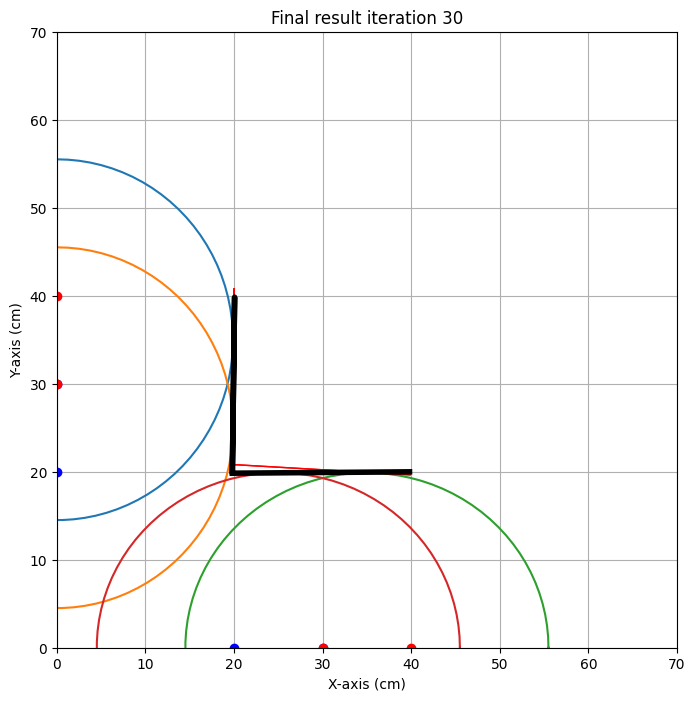

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,41],
    [0,30,0,20,41],
    #[0,10,0,20,260],
    [40,0,30,0,41],
    [30,0,20,0,41],
    #[10,0,20,0,260],
    #[10,0,0,10,260]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 19.8 cm met een standaardafwijking van 0.1 cm 
y0: 19.8 cm met een standaardafwijking van 1.0 cm 
alpha: 0.4 graden met een standaardafwijking van 3.8 graad 
beta: 0.7 graden met een standaardafwijking van 0.5 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Thijn Holswilder]
Voeg een foto in van het algoritme van het enigste groepslid
<img src="algoritme1-schets.jpeg" width="400">


## Opdracht 6: Test iteratie 0.

### simpele eigen geschreven algortime

In [6]:
import numpy as np

threshold = 50

xr = np.arange(0, 35, 5)
xs = xr + 10
x_mid = (xr + xs) / 2

R_x = np.array([170, 170, 170, 41, 41, 41, 41]) / 2

links = 0
rechts = 40

for i in range(len(x_mid)):
    if R_x[i] < threshold:
        if x_mid[i] < rechts:
            rechts = x_mid[i]
    else:
        if x_mid[i] > links:
            links = x_mid[i]

x0 = (links + rechts) / 2
print("x0 =", x0)



yr = np.arange(0, 30, 5) 
ys = yr + 10
y_mid = (yr + ys) / 2

R_y = np.array([170, 170, 170, 41, 41, 41, 41]) / 2

onder = 0
boven = 40

for i in range(len(y_mid)):
    if R_y[i] < threshold:
        if y_mid[i] < boven:
            boven = y_mid[i]
    else:
        if y_mid[i] > onder:
            onder = y_mid[i]

y0 = (onder + boven) / 2
print("y0 =", y0)

import numpy as np

R_alpha =  41 /2
R_beta =   41 /2

x_max = 40
y_max = 40

alpha = np.rad2deg(np.arctan((R_alpha - y0) / (y_max - x0)))
beta  = np.rad2deg(np.arctan((R_beta  - x0) / (x_max - y0)))

print("alpha =", alpha)
print("beta =", beta)


x0 = 17.5
y0 = 17.5
alpha = 7.594643368591445
beta = 7.594643368591445


In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 20,  #zelf aanvullen,
           'y0': 20,  #zelf aanvullen,
           'alpha' : 0, #zelf aanvullen,
           'beta' : 0 #zelf aanvullen},
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Thijn Holswilder' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
            # [10,0,0,0,170],
            # [15,0,5,0,170],
            # [20,0,10,0,170],
            [25,0,15,0,41],
            [30,0,20,0,41],
            [35,0,25,0,41],
            [40,0,30,0,41],

            # [0,10,0,0,170],
            # [0,15,0,5,170],
            # [0,20,0,10,170],
            [0,25,0,15,41],
            [0,30,0,20,41],
            [0,35,0,25,41],
            [0,40,0,30,41]
        ]
)
}

## Opdracht 7: Evaluatie.

Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  25   0  15   0  41
1  30   0  20   0  41
2  35   0  25   0  41
3  40   0  30   0  41
4   0  25   0  15  41
5   0  30   0  20  41
6   0  35   0  25  41
7   0  40   0  30  41


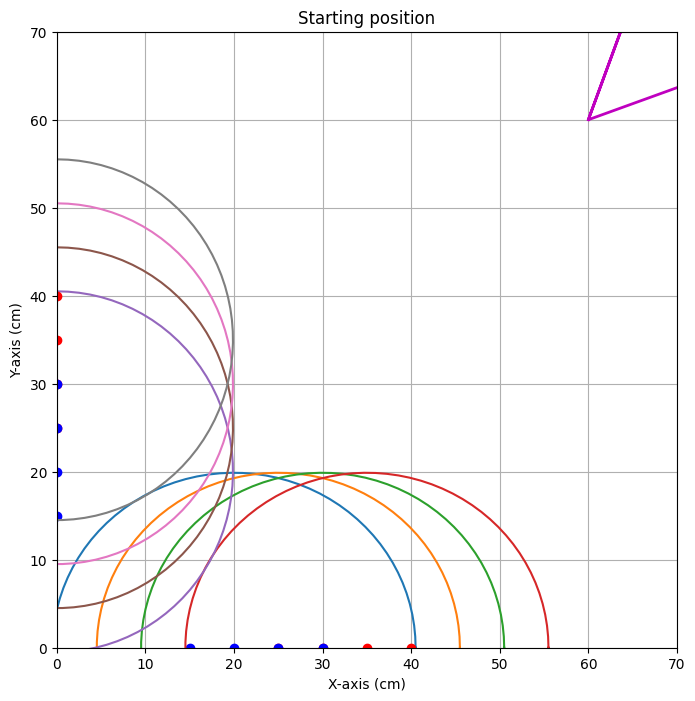


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=103.381


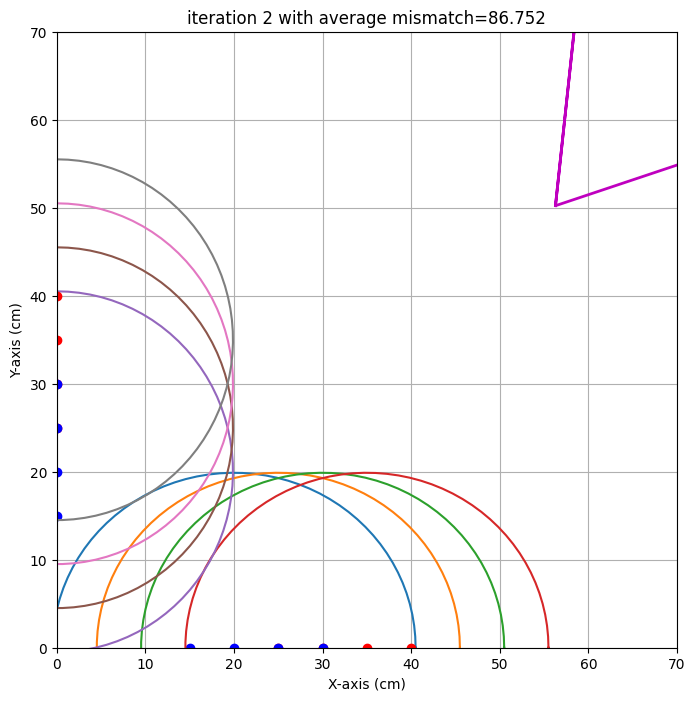

end iteration 2 with average mismatch=86.752


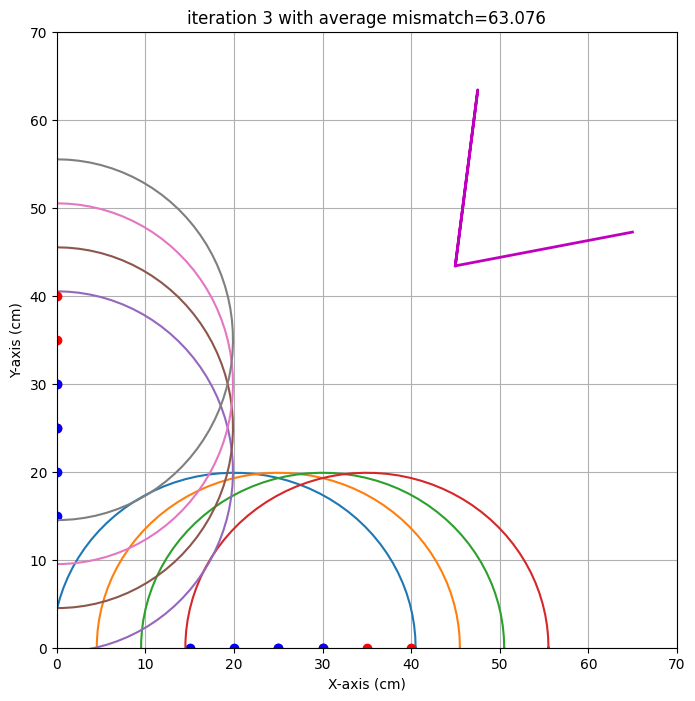

end iteration 3 with average mismatch=63.076


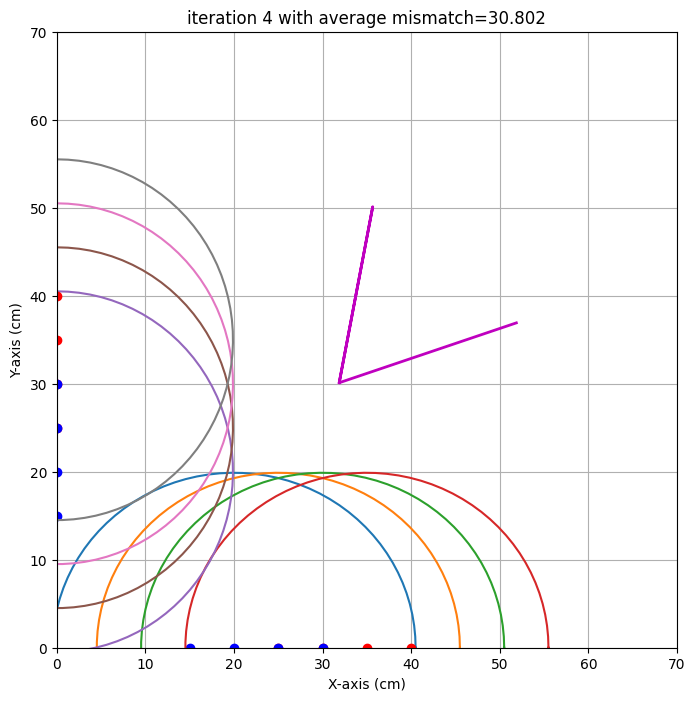

end iteration 4 with average mismatch=30.802


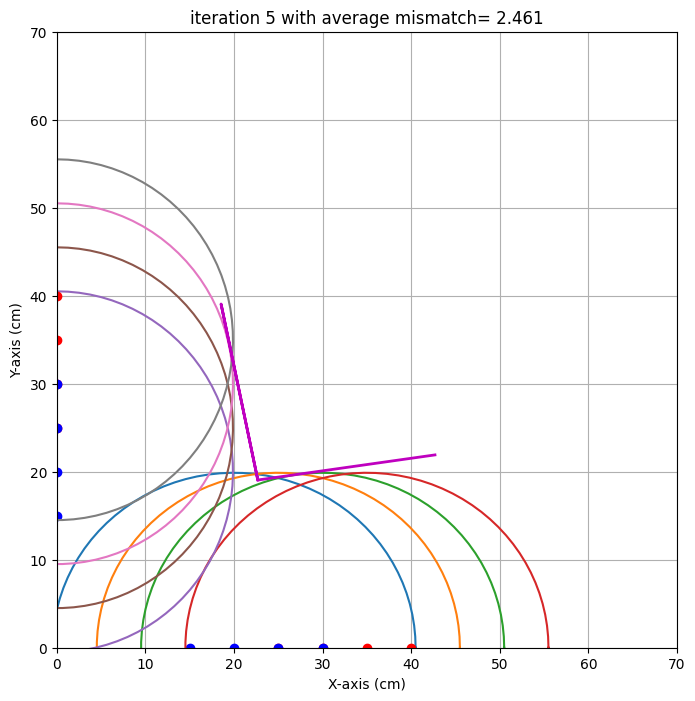

end iteration 5 with average mismatch= 2.461


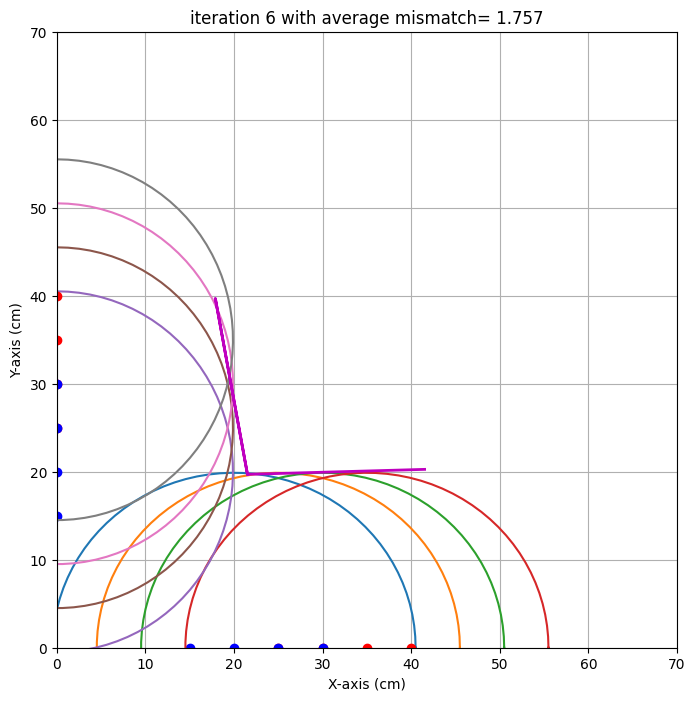

end iteration 6 with average mismatch= 1.757
end iteration 7 with average mismatch= 1.757


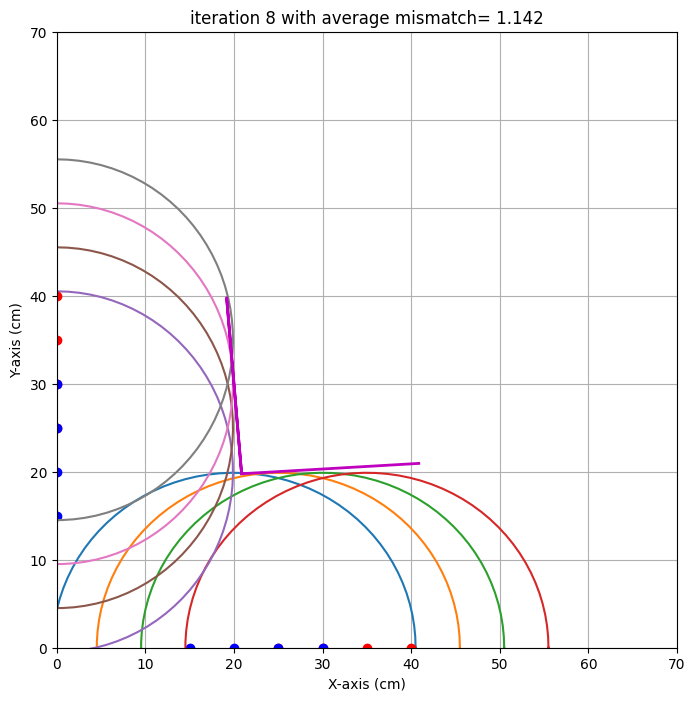

end iteration 8 with average mismatch= 1.142
end iteration 9 with average mismatch= 1.096
end iteration 10 with average mismatch= 1.084


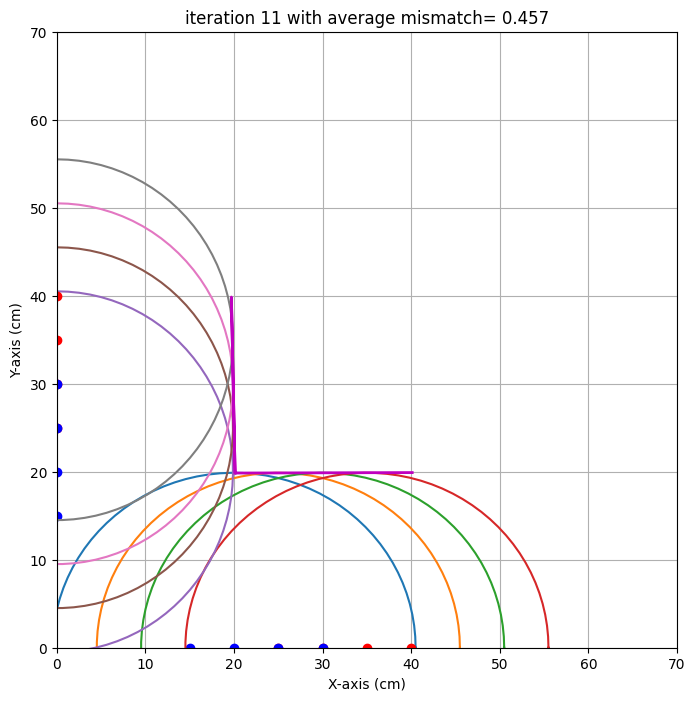

end iteration 11 with average mismatch= 0.457
end iteration 12 with average mismatch= 0.457
end iteration 13 with average mismatch= 0.457
end iteration 14 with average mismatch= 0.457


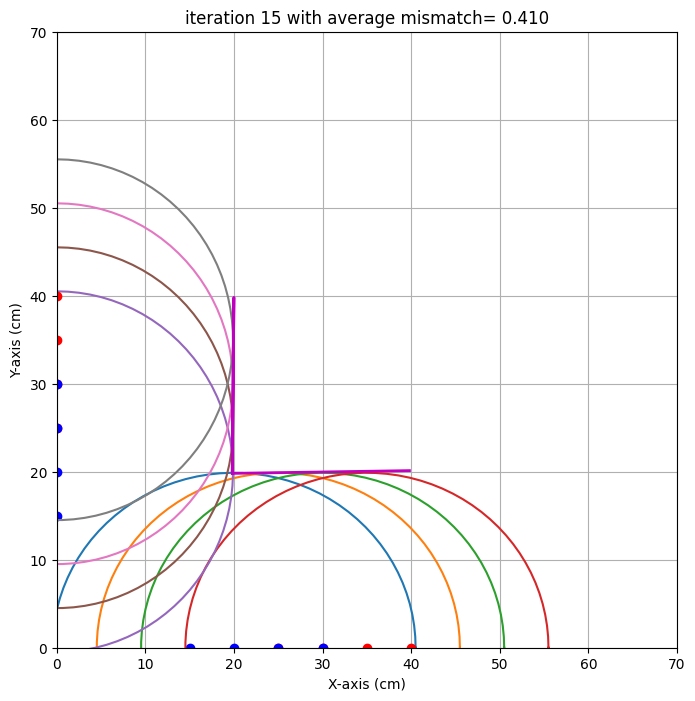

end iteration 15 with average mismatch= 0.410
end iteration 16 with average mismatch= 0.410
end iteration 17 with average mismatch= 0.410
end iteration 18 with average mismatch= 0.410
end iteration 19 with average mismatch= 0.410
end iteration 20 with average mismatch= 0.410


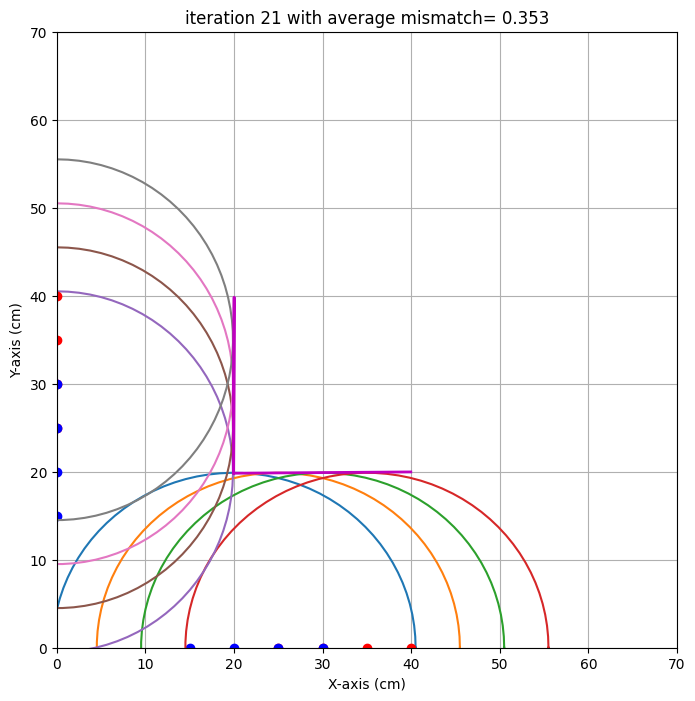

end iteration 21 with average mismatch= 0.353
end iteration 22 with average mismatch= 0.351
end iteration 23 with average mismatch= 0.351
end iteration 24 with average mismatch= 0.351
end iteration 25 with average mismatch= 0.351
end iteration 26 with average mismatch= 0.351
end iteration 27 with average mismatch= 0.351
end iteration 28 with average mismatch= 0.351
end iteration 29 with average mismatch= 0.351
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.351
###############################################################################
end of iteration  30
Best alpha=   0.42 with uncertainty=   0.00
Best beta =   0.16 with uncertainty=   0.00
Best x0   =  19.95 with uncertainty=   0.00
Best y0   =  19.83 with uncertainty=   0.00
###############################################################################
no uncertainty found, pl

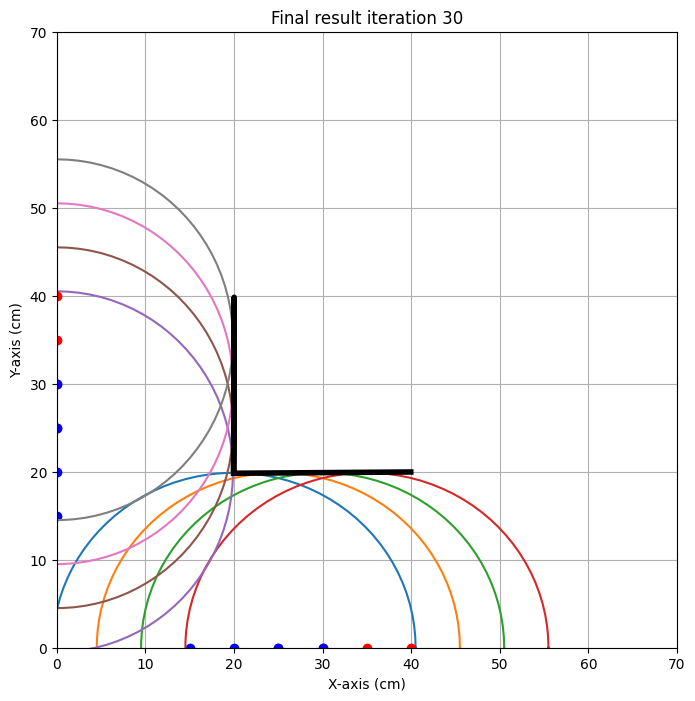

{'alpha': np.float64(0.41663867632419765), 'alpha_eps': 0.0, 'beta': np.float64(0.16491405505975495), 'beta_eps': 0.0, 'x0': np.float64(19.95246566549403), 'x0_eps': 0.0, 'y0': np.float64(19.825100645053585), 'y0_eps': 0.0}


In [8]:
# Hier runnen we het imaging algoritme:

resultaat = imagingDEF.imagingDEF(data['Thijn Holswilder'])
print(resultaat)


In [9]:
studentName = 'Thijn Holswilder'

txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt += 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt += 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt += 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'

print(txt.format(
    naam=studentName,
    x0Target=targets['x0'],
    x0=resultaat['x0'],
    x0_eps=resultaat['x0_eps'],
    y0Target=targets['y0'],
    y0=resultaat['y0'],
    y0_eps=resultaat['y0_eps'],
    alphaTarget=targets['alpha'],
    alpha=resultaat['alpha'],
    alpha_eps=resultaat['alpha_eps'],
    betaTarget=targets['beta'],
    beta=resultaat['beta'],
    beta_eps=resultaat['beta_eps']
))

Thijn Holswilder 
x0 target is : 20.0. Gevonden waarde: 20.0 cm met een standaardafwijking van 0.0 cm 
y0 target is : 20.0. Gevonden waarde: 19.8 cm met een standaardafwijking van 0.0 cm 
alpha target is : 0.0. Gevonden waarde: 0.4 graden met een standaardafwijking van 0.0 graad 
beta target is : 0.0. Gevonden waarde: 0.2 graden met een standaardafwijking van 0.0 graad 



In [10]:
studentName = 'Thijn Holswilder'

txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt += 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt += 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt += 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'

print(txt.format(
    naam=studentName,
    x0Target=targets['x0'],
    x0=resultaat['x0'],
    x0_eps=resultaat['x0_eps'],
    y0Target=targets['y0'],
    y0=resultaat['y0'],
    y0_eps=resultaat['y0_eps'],
    alphaTarget=targets['alpha'],
    alpha=resultaat['alpha'],
    alpha_eps=resultaat['alpha_eps'],
    betaTarget=targets['beta'],
    beta=resultaat['beta'],
    beta_eps=resultaat['beta_eps']
))

Thijn Holswilder 
x0 target is : 20.0. Gevonden waarde: 20.0 cm met een standaardafwijking van 0.0 cm 
y0 target is : 20.0. Gevonden waarde: 19.8 cm met een standaardafwijking van 0.0 cm 
alpha target is : 0.0. Gevonden waarde: 0.4 graden met een standaardafwijking van 0.0 graad 
beta target is : 0.0. Gevonden waarde: 0.2 graden met een standaardafwijking van 0.0 graad 



## Opdracht 8: Iteratie1+.tijd komt niet overeen met de dag van de opdracht voor mij.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](algoritme2-schets.jpeg)


## Opdracht 9: Iteratie 1+ meeting en test

In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 37 ,  #zelf aanvullen,
           'y0': 45,  #zelf aanvullen,
           'alpha' : 7, #zelf aanvullen,
           'beta' : 4 #zelf aanvullen},
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data1 ={'Thijn Holswilder' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
            [0,60,0,50,75.76],
            [0,50,0,40,76.30],
            [0,55,0,45,75.12],
            #[0,40,0,30,200],

            [60,0,50,0,94.17],
            [50,0,40,0,92.30]
            #[40,0,30,0,200]
]
)
}

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  60   0  50  75.76
1   0  50   0  40  76.30
2   0  55   0  45  75.12
3  60   0  50   0  94.17
4  50   0  40   0  92.30


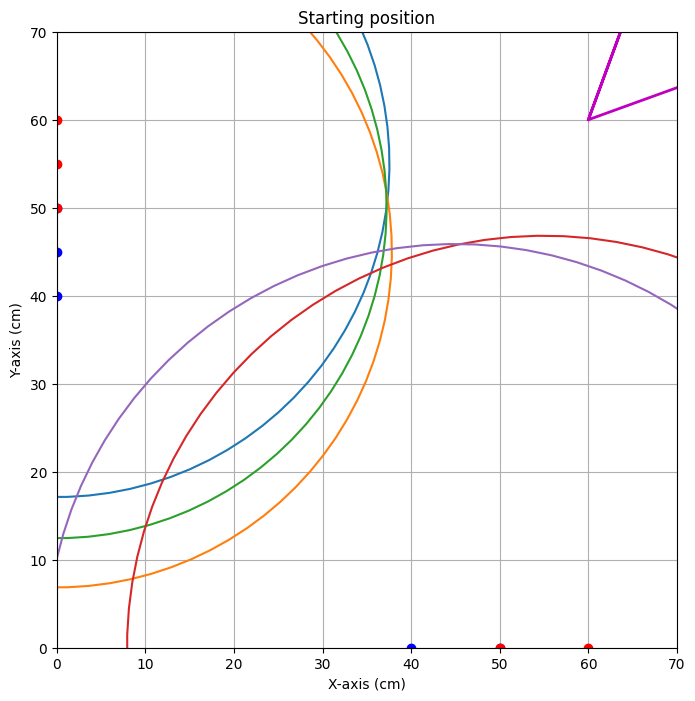


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=45.136


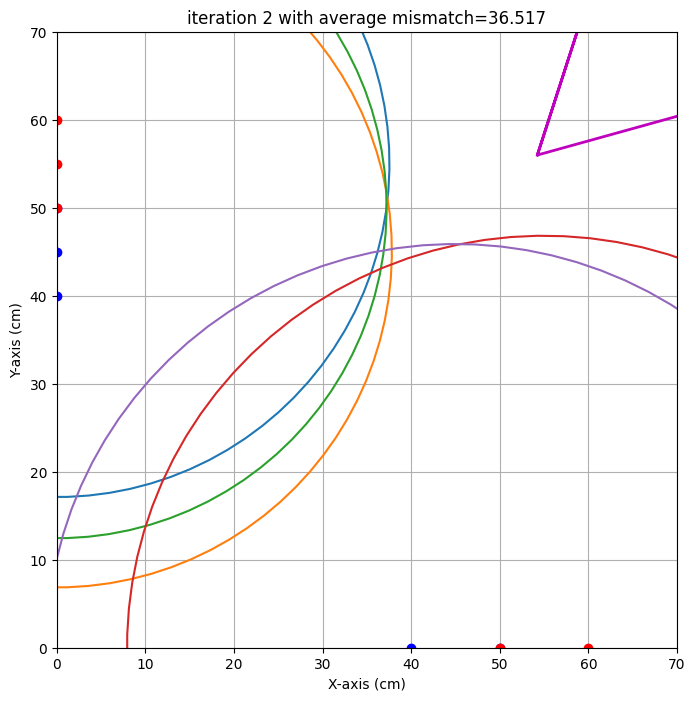

end iteration 2 with average mismatch=36.517


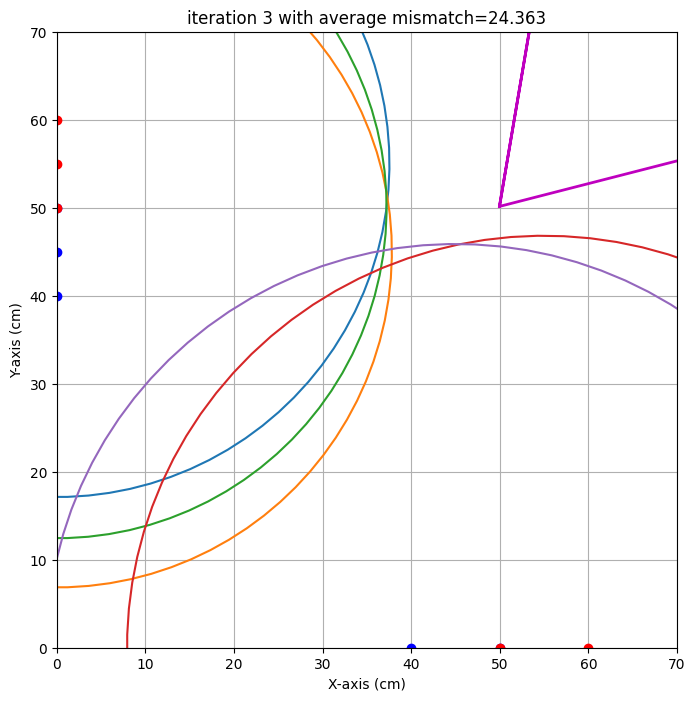

end iteration 3 with average mismatch=24.363


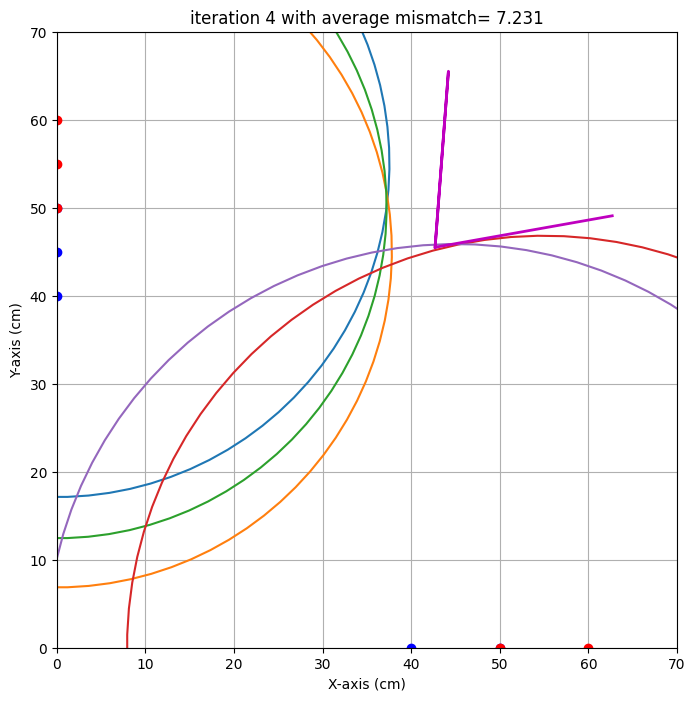

end iteration 4 with average mismatch= 7.231


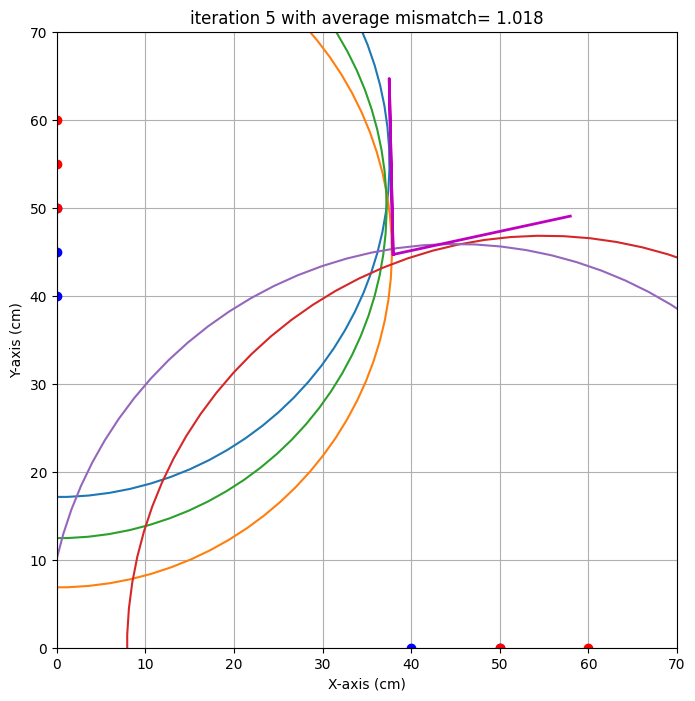

end iteration 5 with average mismatch= 1.018


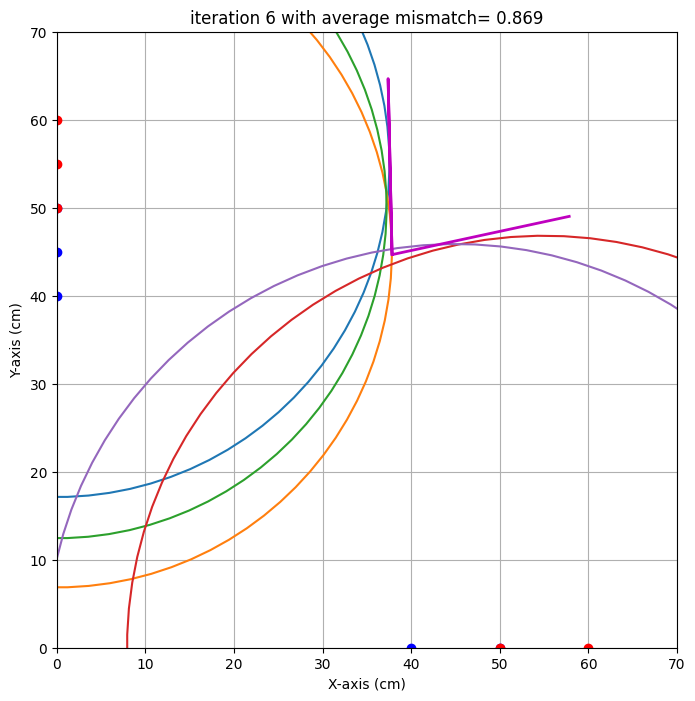

end iteration 6 with average mismatch= 0.869


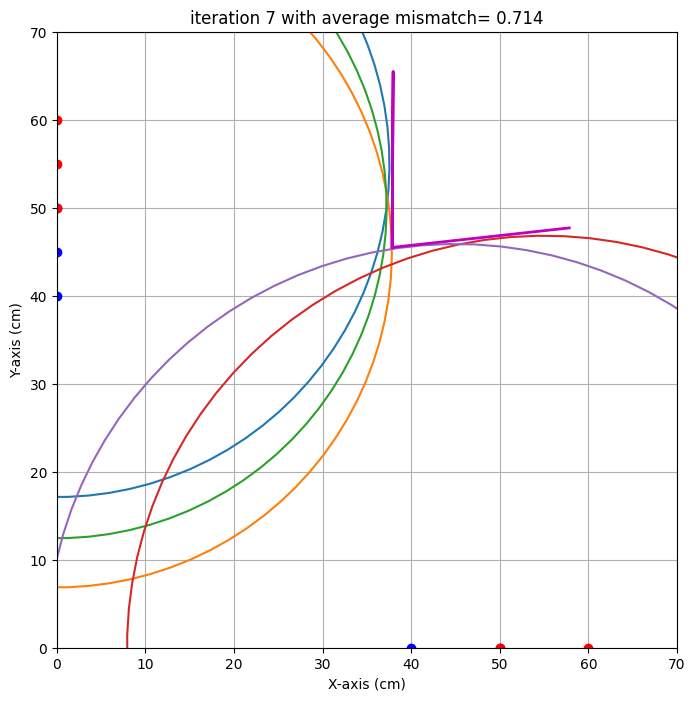

end iteration 7 with average mismatch= 0.714
end iteration 8 with average mismatch= 0.652
end iteration 9 with average mismatch= 0.592
end iteration 10 with average mismatch= 0.580
end iteration 11 with average mismatch= 0.579
end iteration 12 with average mismatch= 0.579
end iteration 13 with average mismatch= 0.579
end iteration 14 with average mismatch= 0.579
end iteration 15 with average mismatch= 0.579
end iteration 16 with average mismatch= 0.579
end iteration 17 with average mismatch= 0.579
end iteration 18 with average mismatch= 0.579
end iteration 19 with average mismatch= 0.564
end iteration 20 with average mismatch= 0.534
end iteration 21 with average mismatch= 0.521


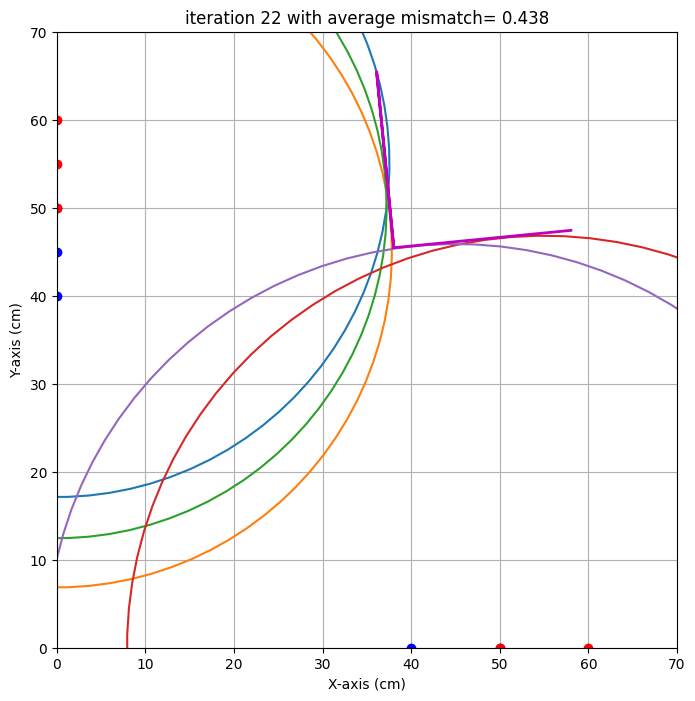

end iteration 22 with average mismatch= 0.438
end iteration 23 with average mismatch= 0.429
end iteration 24 with average mismatch= 0.426
end iteration 25 with average mismatch= 0.425
end iteration 26 with average mismatch= 0.425
end iteration 27 with average mismatch= 0.424
end iteration 28 with average mismatch= 0.424
end iteration 29 with average mismatch= 0.424
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.424
###############################################################################
end of iteration  30
Best alpha=   5.64 with uncertainty=   2.75
Best beta =  -5.56 with uncertainty=   5.95
Best x0   =  38.00 with uncertainty=   0.56
Best y0   =  45.44 with uncertainty=   0.41
###############################################################################


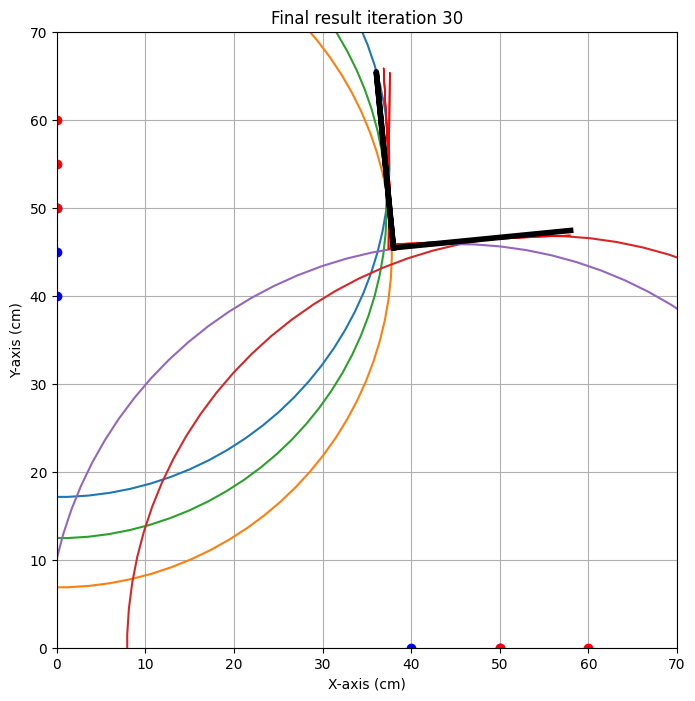

{'alpha': np.float64(5.635402872844101), 'alpha_eps': np.float64(2.7546389168253236), 'beta': np.float64(-5.557728303555558), 'beta_eps': np.float64(5.951153098154038), 'x0': np.float64(38.00239185302228), 'x0_eps': np.float64(0.5633654128858296), 'y0': np.float64(45.44346965172674), 'y0_eps': np.float64(0.4126727239927632)}


In [12]:
resultaat = imagingDEF.imagingDEF(data1['Thijn Holswilder'])
print(resultaat)

In [13]:
studentName = 'Thijn Holswilder'

txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt += 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt += 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt += 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'

print(txt.format(
    naam=studentName,
    x0Target=targets['x0'],
    x0=resultaat['x0'],
    x0_eps=resultaat['x0_eps'],
    y0Target=targets['y0'],
    y0=resultaat['y0'],
    y0_eps=resultaat['y0_eps'],
    alphaTarget=targets['alpha'],
    alpha=resultaat['alpha'],
    alpha_eps=resultaat['alpha_eps'],
    betaTarget=targets['beta'],
    beta=resultaat['beta'],
    beta_eps=resultaat['beta_eps']
))

Thijn Holswilder 
x0 target is : 37.0. Gevonden waarde: 38.0 cm met een standaardafwijking van 0.6 cm 
y0 target is : 45.0. Gevonden waarde: 45.4 cm met een standaardafwijking van 0.4 cm 
alpha target is : 7.0. Gevonden waarde: 5.6 graden met een standaardafwijking van 2.8 graad 
beta target is : 4.0. Gevonden waarde: -5.6 graden met een standaardafwijking van 6.0 graad 



## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

In [14]:
#omdat ik geen TA heb om dit te controleren doen we het alsvolgd:
import random

random.seed(69)
print(f'x0 = {random.randint(0, 30) + 20}')
random.seed(67)
print(f'y0 = {random.randint(0, 30) + 20}')
random.seed(6969)
print(f'alpha = {random.randint(0, 30) - 15}')
random.seed(6767)
print(f'beta = {random.randint(0, 30) - 15}')

# ik zal proberen de hoek en (x0,y0) zo nauwkeurig mogelijk neer te zetten 

x0 = 41
y0 = 22
alpha = -13
beta = 6


#### Laatste definitieve algoritme dus eigelijk iteratie 2

Figuur: ![Alt](algoritme3-schets.jpeg)

In [15]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'x0': 41, # zelf aanvullen,
            'y0': 22, # zelf aanvullen,
            'alpha' : -13, # zelf aanvullen,
            'beta' : 6 # zelf aanvullen
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'Thijn Holswilder' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
            #[0,60,0,50,200],
            [0,50,0,40,84.50],
            [0,40,0,30,82.70],
            [0,45,0,35,82.50],

            [60,0,50,0,42.10],
            [50,0,40,0,44.60],
            [55,0,45,0,43.50]
            #[40,0,30,0,200]
]
)
}

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  50   0  40  84.5
1   0  40   0  30  82.7
2   0  45   0  35  82.5
3  60   0  50   0  42.1
4  50   0  40   0  44.6
5  55   0  45   0  43.5


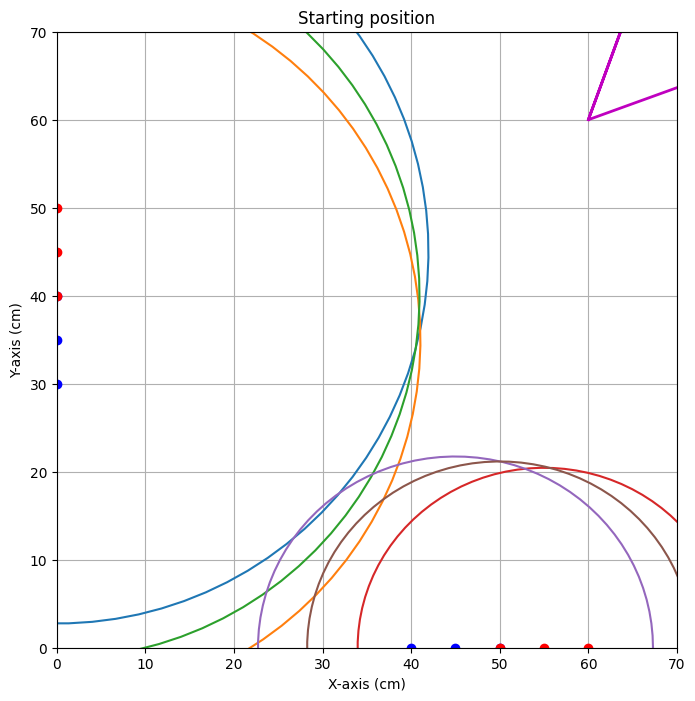


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=68.166


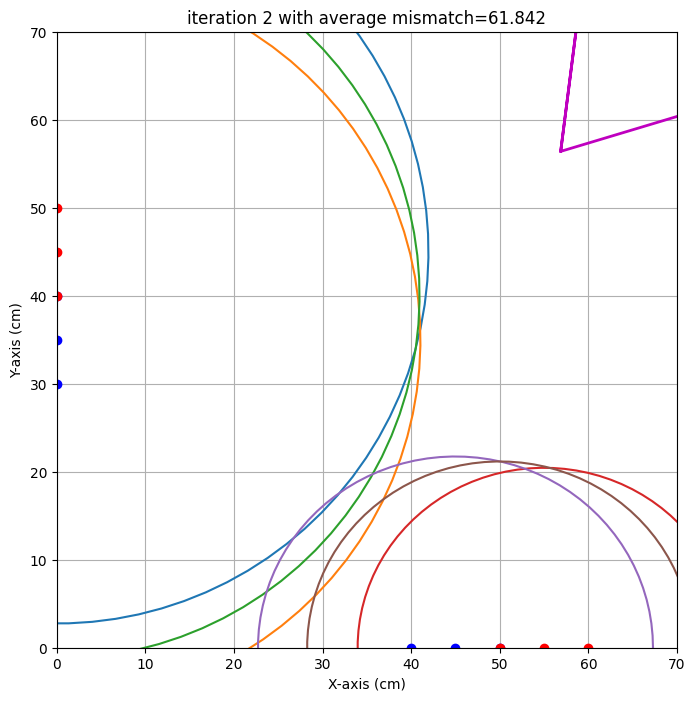

end iteration 2 with average mismatch=61.842


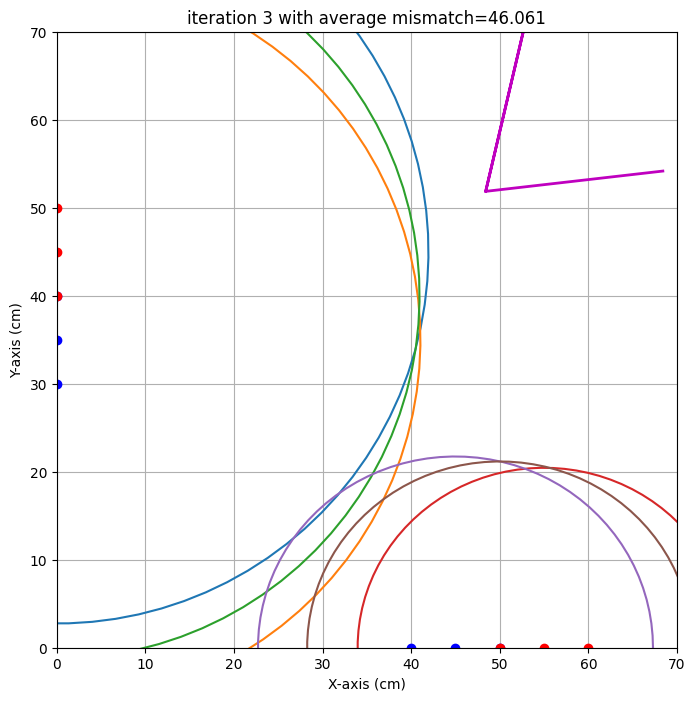

end iteration 3 with average mismatch=46.061


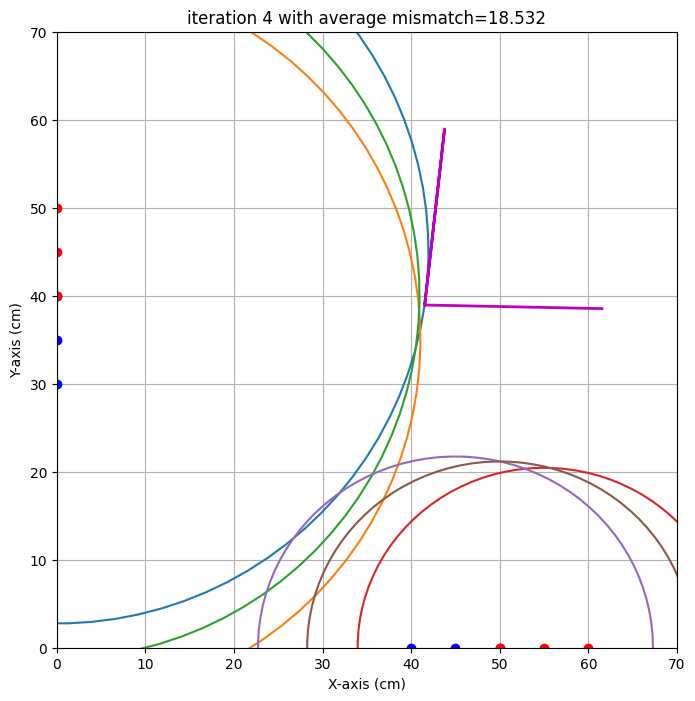

end iteration 4 with average mismatch=18.532


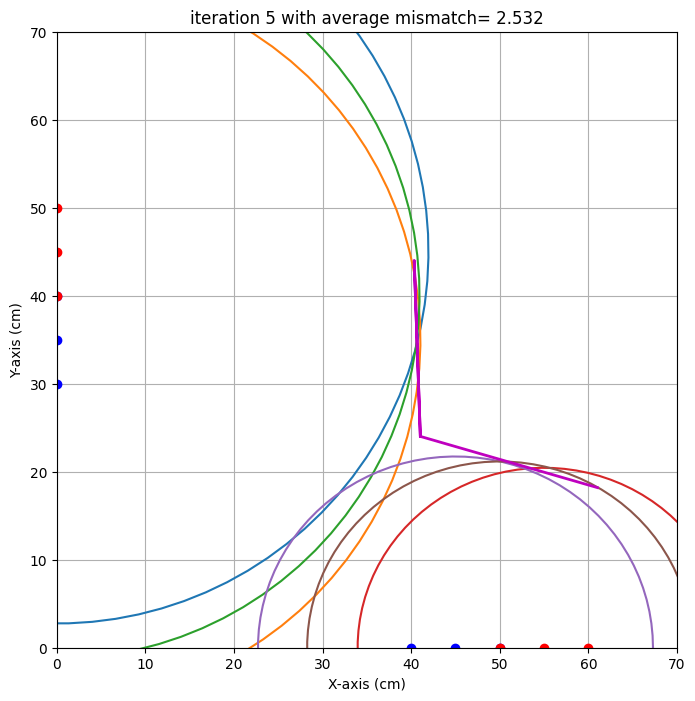

end iteration 5 with average mismatch= 2.532


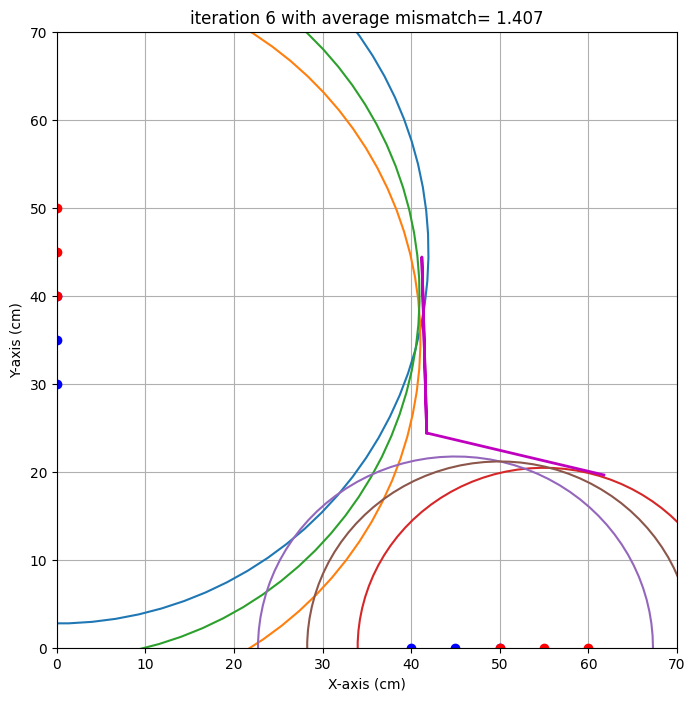

end iteration 6 with average mismatch= 1.407


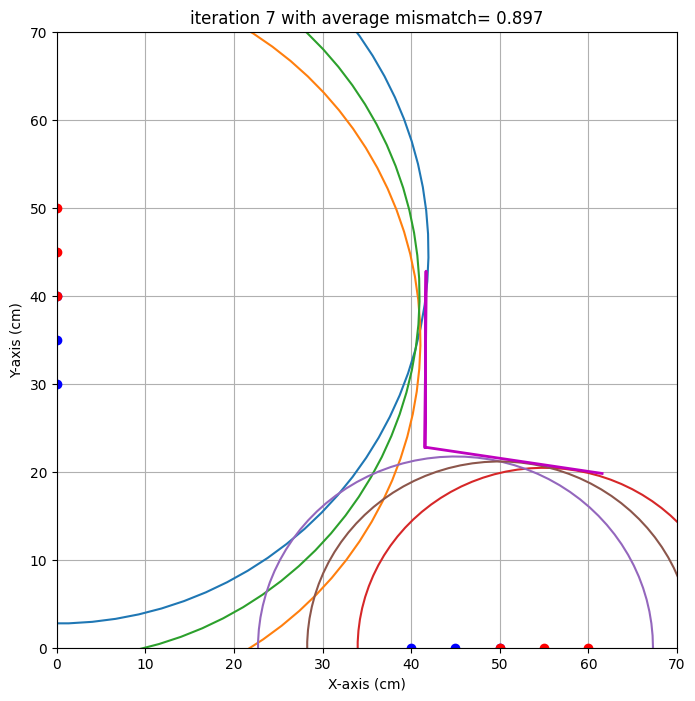

end iteration 7 with average mismatch= 0.897


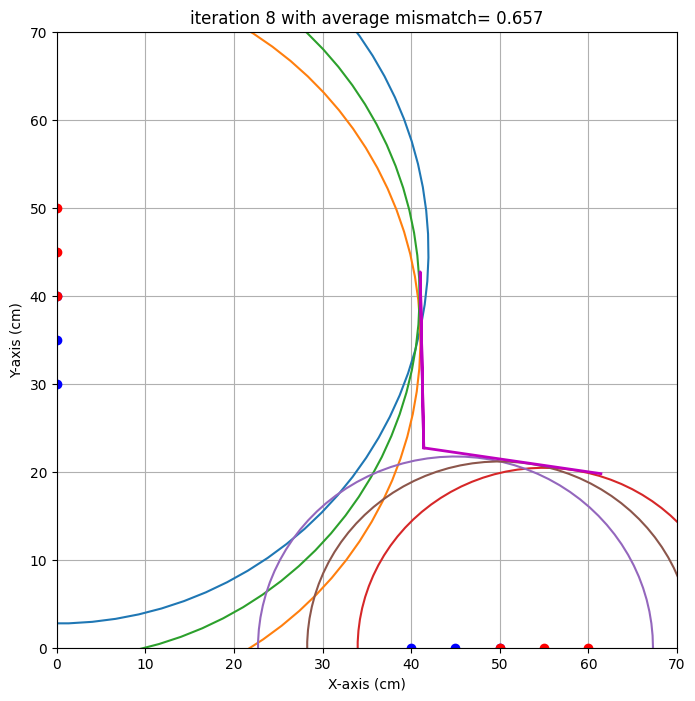

end iteration 8 with average mismatch= 0.657
end iteration 9 with average mismatch= 0.635
end iteration 10 with average mismatch= 0.635
end iteration 11 with average mismatch= 0.635
end iteration 12 with average mismatch= 0.635
end iteration 13 with average mismatch= 0.635
end iteration 14 with average mismatch= 0.635
end iteration 15 with average mismatch= 0.635
end iteration 16 with average mismatch= 0.635
end iteration 17 with average mismatch= 0.635
end iteration 18 with average mismatch= 0.635
end iteration 19 with average mismatch= 0.629


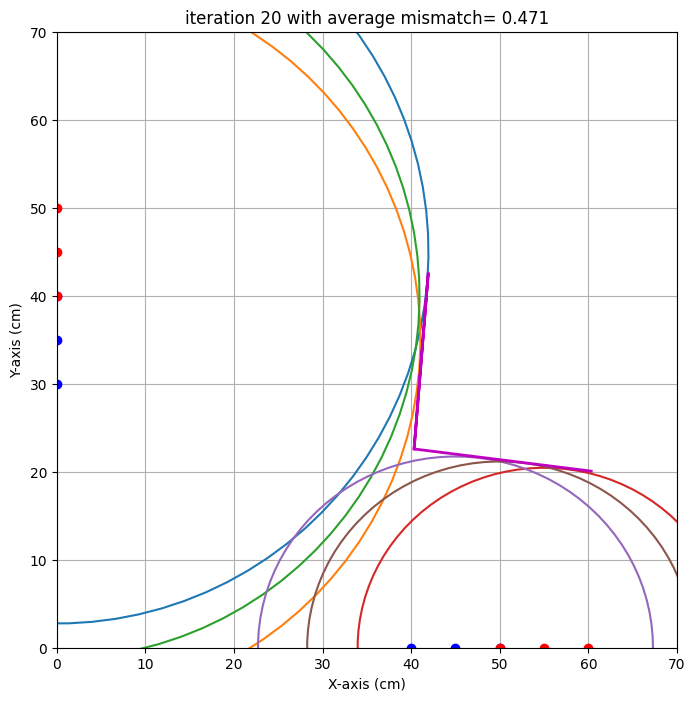

end iteration 20 with average mismatch= 0.471
end iteration 21 with average mismatch= 0.439
end iteration 22 with average mismatch= 0.423
end iteration 23 with average mismatch= 0.404
end iteration 24 with average mismatch= 0.378
end iteration 25 with average mismatch= 0.370
end iteration 26 with average mismatch= 0.369
end iteration 27 with average mismatch= 0.369
end iteration 28 with average mismatch= 0.369
end iteration 29 with average mismatch= 0.368
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.368
###############################################################################
end of iteration  30
Best alpha=  -8.52 with uncertainty=   2.27
Best beta =   5.47 with uncertainty=   4.00
Best x0   =  40.11 with uncertainty=   1.11
Best y0   =  22.91 with uncertainty=   0.40
##########################################################

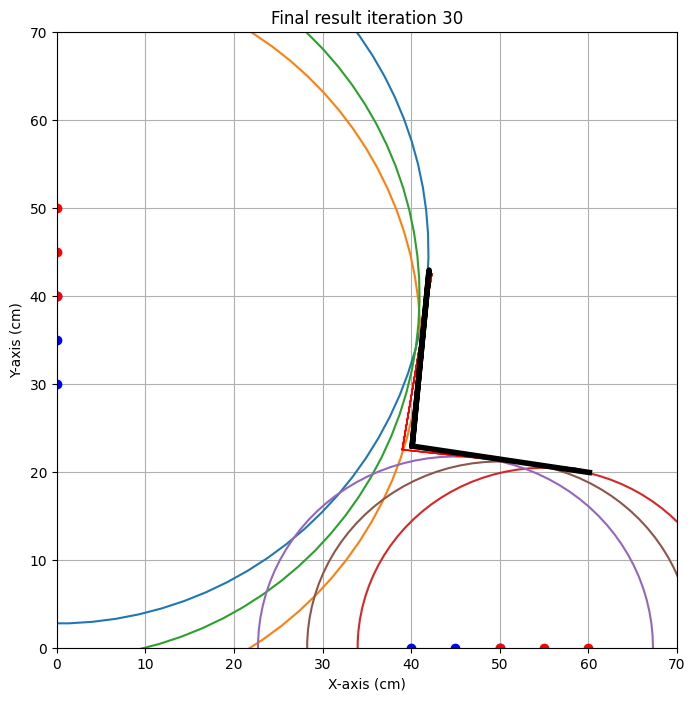

{'alpha': np.float64(-8.52150984524372), 'alpha_eps': np.float64(2.2735444525600865), 'beta': np.float64(5.467021198573514), 'beta_eps': np.float64(4.0012898491072715), 'x0': np.float64(40.10930345399057), 'x0_eps': np.float64(1.1112023312201416), 'y0': np.float64(22.91068967886646), 'y0_eps': np.float64(0.4043359570175653)}


In [16]:
resultaat = imagingDEF.imagingDEF(dataFinalCheck['Thijn Holswilder'])
print(resultaat)

In [17]:
studentName = 'Thijn Holswilder'

txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt += 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt += 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt += 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'

print(txt.format(
    naam=studentName,
    x0Target=targets['x0'],
    x0=resultaat['x0'],
    x0_eps=resultaat['x0_eps'],
    y0Target=targets['y0'],
    y0=resultaat['y0'],
    y0_eps=resultaat['y0_eps'],
    alphaTarget=targets['alpha'],
    alpha=resultaat['alpha'],
    alpha_eps=resultaat['alpha_eps'],
    betaTarget=targets['beta'],
    beta=resultaat['beta'],
    beta_eps=resultaat['beta_eps']
))

Thijn Holswilder 
x0 target is : 41.0. Gevonden waarde: 40.1 cm met een standaardafwijking van 1.1 cm 
y0 target is : 22.0. Gevonden waarde: 22.9 cm met een standaardafwijking van 0.4 cm 
alpha target is : -13.0. Gevonden waarde: -8.5 graden met een standaardafwijking van 2.3 graad 
beta target is : 6.0. Gevonden waarde: 5.5 graden met een standaardafwijking van 4.0 graad 



## Opdracht 11: Leerdoelen.
Figuur: ![Alt](algoritme1-schets.jpeg "algoritme versie 1")

Figuur: ![Alt](algoritme2-schets.jpeg "algoritme versie 2")

Figuur: ![Alt](algoritme3-schets.jpeg "algoritme versie 3")